In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile
import os

zip_file = "archive (1).zip"

extract_path = "/content/mri_dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [3]:
import os

for root, dirs, files in os.walk("/content/mri_dataset"):
    print(root)


/content/mri_dataset
/content/mri_dataset/Brain_Tumor_Datasets
/content/mri_dataset/Brain_Tumor_Datasets/test
/content/mri_dataset/Brain_Tumor_Datasets/test/no
/content/mri_dataset/Brain_Tumor_Datasets/test/yes
/content/mri_dataset/Brain_Tumor_Datasets/train
/content/mri_dataset/Brain_Tumor_Datasets/train/no
/content/mri_dataset/Brain_Tumor_Datasets/train/yes


In [4]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_dir = "/content/mri_dataset/Training"
test_dir = "/content/mri_dataset/Testing"

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_data.class_names

print("Classes:", class_names)

FileNotFoundError: [Errno 2] No such file or directory: '/content/mri_dataset/Training'

In [5]:
import os

for root, dirs, files in os.walk("/content/mri_dataset"):
    print(root)

/content/mri_dataset
/content/mri_dataset/Brain_Tumor_Datasets
/content/mri_dataset/Brain_Tumor_Datasets/test
/content/mri_dataset/Brain_Tumor_Datasets/test/no
/content/mri_dataset/Brain_Tumor_Datasets/test/yes
/content/mri_dataset/Brain_Tumor_Datasets/train
/content/mri_dataset/Brain_Tumor_Datasets/train/no
/content/mri_dataset/Brain_Tumor_Datasets/train/yes


In [6]:
import os

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/content/mri_dataset"):
    for d in dirs:
        if d.lower() == "training":
            train_dir = os.path.join(root, d)

        if d.lower() == "testing":
            test_dir = os.path.join(root, d)

print("Training folder:", train_dir)
print("Testing folder:", test_dir)

Training folder: None
Testing folder: None


In [7]:
import zipfile

zip_file = "/content/archive (1).zip"

with zipfile.ZipFile(zip_file, "r") as z:
    print("Files and folders inside the ZIP:\n")
    for name in z.namelist()[:100]:
        print(name)

Files and folders inside the ZIP:

Brain_Tumor_Datasets/test/no/12 no.jpg
Brain_Tumor_Datasets/test/no/13 no.jpg
Brain_Tumor_Datasets/test/no/17 no.jpg
Brain_Tumor_Datasets/test/no/18 no.jpg
Brain_Tumor_Datasets/test/no/24 no.jpg
Brain_Tumor_Datasets/test/no/31 no.jpg
Brain_Tumor_Datasets/test/no/34 no.jpg
Brain_Tumor_Datasets/test/no/35 no.jpg
Brain_Tumor_Datasets/test/no/39 no.jpg
Brain_Tumor_Datasets/test/no/42 no.jpg
Brain_Tumor_Datasets/test/no/7 no.jpg
Brain_Tumor_Datasets/test/no/N17.jpg
Brain_Tumor_Datasets/test/no/N26.JPG
Brain_Tumor_Datasets/test/no/N3.jpg
Brain_Tumor_Datasets/test/no/No16.jpg
Brain_Tumor_Datasets/test/no/No20.jpg
Brain_Tumor_Datasets/test/no/Te-noTr_0003.jpg
Brain_Tumor_Datasets/test/no/Te-noTr_0006.jpg
Brain_Tumor_Datasets/test/no/Te-noTr_0009.jpg
Brain_Tumor_Datasets/test/no/Te-no_0015.jpg
Brain_Tumor_Datasets/test/no/Te-no_0028.jpg
Brain_Tumor_Datasets/test/no/Te-no_0029.jpg
Brain_Tumor_Datasets/test/no/Te-no_0032.jpg
Brain_Tumor_Datasets/test/no/Te-no_00

In [8]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_dir = "/content/mri_dataset/Brain_Tumor_Datasets/train"
test_dir = "/content/mri_dataset/Brain_Tumor_Datasets/test"

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_data.class_names

print("Classes:", class_names)
print("Dataset loaded successfully!")

Found 7012 files belonging to 2 classes.
Found 1752 files belonging to 2 classes.
Classes: ['no', 'yes']
Dataset loaded successfully!


In [9]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model created successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model created successfully!


In [10]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 71s 154ms/step - accuracy: 0.9353 - loss: 0.1826 - val_accuracy: 0.9532 - val_loss: 0.1326
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 67s 152ms/step - accuracy: 0.9539 - loss: 0.1123 - val_accuracy: 0.9623 - val_loss: 0.1081
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 67s 153ms/step - accuracy: 0.9645 - loss: 0.0947 - val_accuracy: 0.9635 - val_loss: 0.1102
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 72s 131ms/step - accuracy: 0.9683 - loss: 0.0813 - val_accuracy: 0.9652 - val_loss: 0.1012
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 67s 152ms/step - accuracy: 0.9740 - loss: 0.0720 - val_accuracy: 0.9697 - val_loss: 0.0853


In [11]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9697 - loss: 0.0853
Test Accuracy: 96.97 %


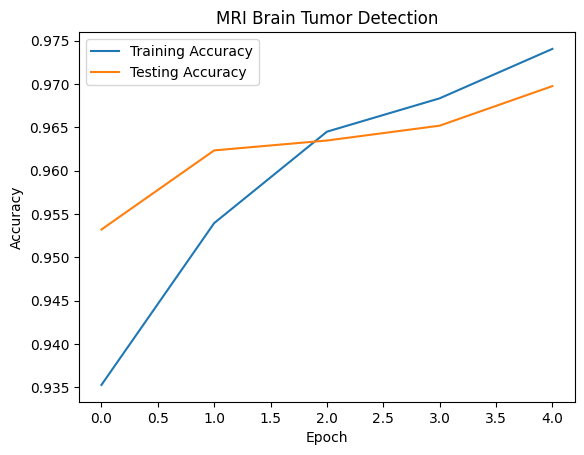

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Testing Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MRI Brain Tumor Detection")
plt.legend()
plt.show()

In [14]:
from google.colab import files

uploaded_image = files.upload()

Saving File_Brain_Tumor_MRI.jpg.pdf to File_Brain_Tumor_MRI.jpg.pdf


In [16]:
import os
import glob
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Find MRI images already inside your dataset
image_files = glob.glob(
    "/content/mri_dataset/Brain_Tumor_Datasets/test/yes/*"
)

# Select the first image
image_name = image_files[0]

print("Using image:")
print(image_name)

# Load image
img = load_img(image_name, target_size=(128, 128))

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Using image:
/content/mri_dataset/Brain_Tumor_Datasets/test/yes/Te-gl_0262.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
Prediction: yes
Confidence: 99.99 %


In [17]:
image_files = glob.glob(
    "/content/mri_dataset/Brain_Tumor_Datasets/test/no/*"
)

image_name = image_files[0]

img = load_img(image_name, target_size=(128, 128))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction: no
Confidence: 94.45 %


In [19]:
model.save("/content/brain_tumor_detection_model.keras")

print("Model saved successfully!")

Model saved successfully!
